In [1]:
%load_ext autoreload
%autoreload 2

import os, ctypes
from glob import glob
append_ld_library_path = "~/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
LD_LIBRARY_PATH = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{append_ld_library_path}:{LD_LIBRARY_PATH}" if LD_LIBRARY_PATH else append_ld_library_path

cublas_dir = "/home/ubuntu/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
for pat in ["libcublas.so*", "libcublasLt.so*", "libcudart.so*"]:
    for lib in sorted(glob(os.path.join(cublas_dir, pat))):
        try:
            ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
        except OSError as e:
            print(f"Warning: could not load {lib}: {e}")

import numpy as np
import pickle
import torch
import gc
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

from pathlib import Path
from datetime import datetime
from scipy.optimize import linear_sum_assignment
from huggingface_hub import snapshot_download

from MSA_Pairformer.dataset import esmtok_to_pairformertok_d, aa2tok_d
from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.regression import MRFHead

from MSA_Pairformer.pairing_optimization.mp_em import MP_EM
from MSA_Pairformer.pairing_optimization.mp_pdp import MP_PDP
from MSA_Pairformer.pairing_optimization.msa_parsing import read_msa
from MSA_Pairformer.pairing_optimization.datasets import generate_dataset, dataset_tokenizer

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Set device and load MSA Pairformer to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
msa_pairformer = MSAPairformer.from_pretrained(
    device=device
)
msa_pairformer.eval()
msa_pairformer = torch.compile(msa_pairformer, dynamic=True)

mrf_head = MRFHead(
    dim_pairwise = 256,
    dim_alphabet = 26
)
path = Path(snapshot_download(repo_id="yakiyama/MSA-Pairformer"))
mrf_head_checkpoint = torch.load(path / "mrf_head.bin", weights_only=True, map_location=device)
# Remove "mrf_head." prefix from every key in mrf_head_checkpoint, if it exists
mrf_head_checkpoint = {k.replace("mrf_head.", ""): v for k, v in mrf_head_checkpoint.items()}
mrf_head.load_state_dict(mrf_head_checkpoint)
mrf_head.to(device)

for p in msa_pairformer.parameters():
    p.requires_grad = False
for p in mrf_head.parameters():
    p.requires_grad = False


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Using cuEquivariance for triangle multiplicative update


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

# 1. Pair MSAs using MSA Pairformer Expectation-Maximization (MP-EM)
## 1.1 Histidine kinase + response regulator (HK-RR)

100%|██████████| 500/500 [01:06<00:00,  7.52it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.683377308707124
	Number of correct pairs: 0.8021108179419525


100%|██████████| 500/500 [01:03<00:00,  7.85it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.6130790190735694
	Number of correct pairs: 0.7574931880108992


100%|██████████| 500/500 [01:02<00:00,  7.98it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.5286103542234333
	Number of correct pairs: 0.55858310626703


100%|██████████| 500/500 [01:01<00:00,  8.11it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.6621621621621622
	Number of correct pairs: 0.6756756756756757


100%|██████████| 500/500 [01:00<00:00,  8.23it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.6133720930232558
	Number of correct pairs: 0.7034883720930233


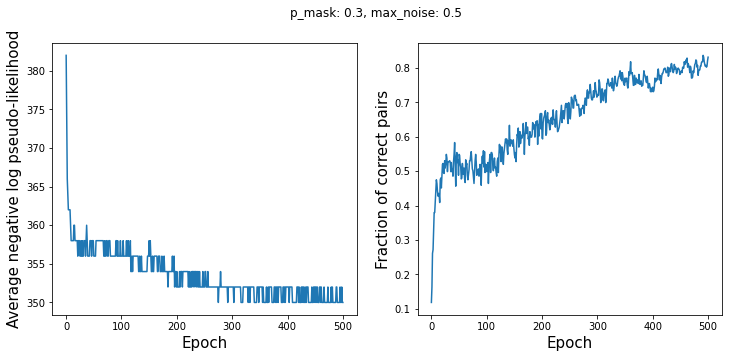

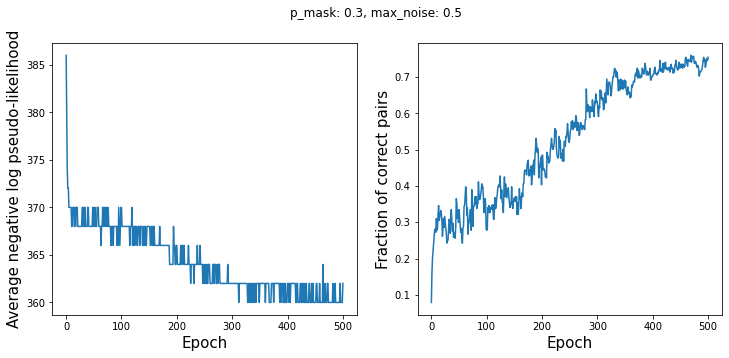

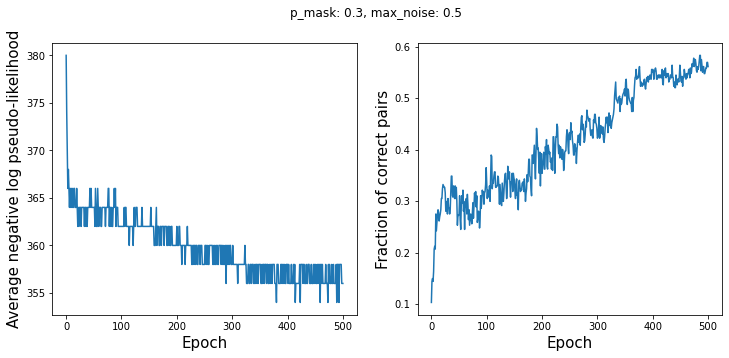

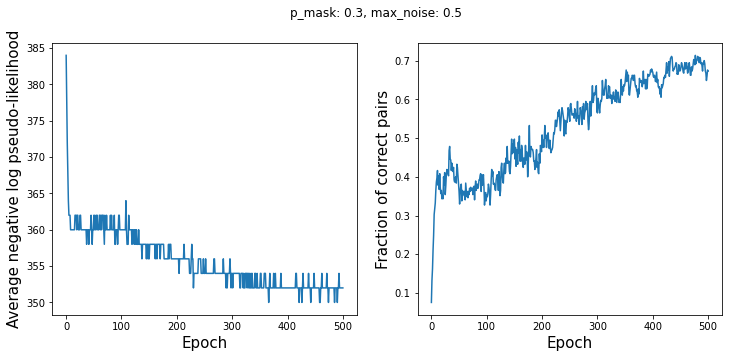

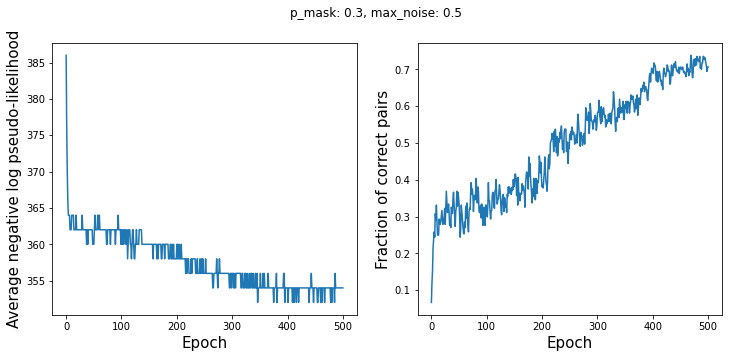

In [3]:
# Load data 
RESULTS_DIR = "results/pairing/hk_rr_384/"
msa_data = [read_msa("../../data/Figure3_toxin_antitoxin/HK_in_Concat_nnn.fasta", -1),
            read_msa("../../data/Figure3_toxin_antitoxin/RR_in_Concat_nnn.fasta", -1)]
get_species_name = (lambda strn: strn.split("|")[1])
nSeqs = 384
EPOCHS = 500

p_mask = 0.3
max_noise = 0.5
min_noise = 0.1
q = 400
ema_alpha = 0
ema_alpha = round(ema_alpha, 1)
n_perm_thresh = np.inf

runtime_stats_d = {}

parameters_train = {
    "epochs": EPOCHS,
    "random_init": True,
    "coverage_threshold_potts_model": 0.7,
    "noise_scheduler": "cosine",
    "max_noise": max_noise,
    "potts_model_ema_alpha": ema_alpha,
    "p_mask": p_mask,
    "min_noise": min_noise,
    "random_init": True,
    "n_perm_thresh": n_perm_thresh
}

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
# Baseline after context is created
baseline_alloc = torch.cuda.memory_allocated()
baseline_resv  = torch.cuda.memory_reserved()
torch.cuda.synchronize()

for seed in range(5):
    parameters_dataset = {
        "N": nSeqs,  # Average number of sequences in the input
        "pos": 0,  # Size of the context pairs to use as positive example 
        "max_size": 100,  # Max size of species MSAs (if same as N there is no limit on size)
        "NUMPY_SEED": seed,
        "NUMPY_SEED_OTHER": seed,
    }
    dataset, species_sizes = generate_dataset(
        parameters_dataset, msa_data, get_species_name=get_species_name, verbose=False
    )
    all_seq_set = set()
    filtered_dataset = {'msa': {'left': [], 'right': []}, 'positive_examples': None}
    for i in range(len(dataset['msa']['left'])):
        curr_seq = dataset['msa']['left'][i][1] + dataset['msa']['right'][i][1]
        if curr_seq not in all_seq_set:
            filtered_dataset['msa']['left'].append(dataset['msa']['left'][i])
            filtered_dataset['msa']['right'].append(dataset['msa']['right'][i])
            all_seq_set.add(curr_seq)
    curr_taxid = get_species_name(dataset['msa']['left'][0][0])
    curr_taxid_size = 1
    filtered_species_sizes = []
    solo_seq_idx_l = []
    for i in range(1, len(filtered_dataset['msa']['left'])):
        if get_species_name(filtered_dataset['msa']['left'][i][0]) == curr_taxid:
            curr_taxid_size += 1
        else:
            if curr_taxid_size == 1:
                solo_seq_idx_l.append(i-1)
            filtered_species_sizes.append(curr_taxid_size)
            curr_taxid = get_species_name(filtered_dataset['msa']['left'][i][0])
            curr_taxid_size = 1
    filtered_species_sizes.append(curr_taxid_size)
    if curr_taxid_size == 1:
        solo_seq_idx_l.append(i)
    tokenized_dataset = dataset_tokenizer(filtered_dataset, device=device)
    # Get ESM tokens and convert to MSA Pairformer tokens
    esm_tokens_left = tokenized_dataset["msa"]["left"].argmax(dim=-1)
    esm_tokens_right = tokenized_dataset["msa"]["right"].argmax(dim=-1)
    # Remove singletons
    nonsingle_mask_t = torch.ones(esm_tokens_left.shape[1], dtype=torch.bool)
    nonsingle_mask_t[solo_seq_idx_l] = False
    esm_tokens_left = esm_tokens_left[:, nonsingle_mask_t, :]
    esm_tokens_right = esm_tokens_right[:, nonsingle_mask_t, :]
    filtered_species_sizes = np.array([s for s in filtered_species_sizes if s > 1])

    # Map ESM tokens to MSA Pairformer tokens and remove CLS token
    mp_tokenized_msa_left_t = torch.from_numpy(
        np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_left.cpu().numpy())
    )[:, :, 1:].cpu()
    mp_tokenized_msa_right_t = torch.from_numpy(
        np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_right.cpu().numpy())
    )[:, :, 1:].cpu()
    # One hot encode the tokens
    mp_ohe_msa_left_t = torch.nn.functional.one_hot(mp_tokenized_msa_left_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
    mp_ohe_msa_right_t = torch.nn.functional.one_hot(mp_tokenized_msa_right_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
    tokenized_dataset["msa"]["left"] = mp_ohe_msa_left_t # (1, N, L_left, 28)
    tokenized_dataset["msa"]["right"] = mp_ohe_msa_right_t # (1, N, L_right, 28)

    left_msa, right_msa = tokenized_dataset["msa"]["left"], tokenized_dataset["msa"]["right"]
    positive_examples = tokenized_dataset["positive_examples"] # empty

    # Designate the first sequence in the MSA as the query sequence
    # This will be a positive example and will be unchanged throughout optimization
    num_positive = 1
    positive_examples = torch.cat(
        (left_msa[:, :num_positive, :, :], right_msa[:, :num_positive, :, :]),
        dim=2
    ).to(device)
    left_msa_train = left_msa[:, num_positive:, :, :]
    right_msa_train = right_msa[:, num_positive:, :, :]
    filtered_species_sizes[0] = filtered_species_sizes[0] - 1
    # Make sure the first species has at least 2 sequences
    if filtered_species_sizes[0] < 2:
        filtered_species_sizes = filtered_species_sizes[1:]
        left_msa_train = left_msa_train[:, 1:, :, :]
        right_msa_train = right_msa_train[:, 1:, :, :]

    parameters_init = {
        "model": msa_pairformer,
        "mrf_head": mrf_head,
        "species_sizes": filtered_species_sizes,
        "device": device,
        "random_seed": seed,
        "compile": False,
        "query_biasing": True,
        "potts_layer_idx": 15
    }
    res_d = {}
    pair_optimizer = MP_EM(**parameters_init)
    start_time = time.time()
    losses, perm_mats, delta_ts = pair_optimizer.train(
        left_msa_train,
        right_msa_train,
        positive_examples=positive_examples,
        **parameters_train
    )
    end_time = time.time()

    f, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(losses)
    ax[0].set_ylabel("Average negative log pseudo-likelihood", size=15)
    ax[0].set_xlabel("Epoch", size=15)
    ax[1].plot([np.trace(perm_mat)/perm_mat.shape[0] for perm_mat in perm_mats])
    ax[1].set_ylabel("Fraction of correct pairs", size=15)
    ax[1].set_xlabel("Epoch", size=15)
    f.suptitle(f"p_mask: {p_mask}, max_noise: {max_noise}")
    print(f"p_mask: {p_mask}, max_noise: {max_noise}")
    print("\tNumber of correct pairs: {}".format(np.trace(perm_mats[np.argmin(losses)]) / np.sum(perm_mats[np.argmin(losses)].shape[0])))

    # Get q lowest losses
    q_lowest_losses = np.argsort(losses)[:q]
    avg_perm_mat = torch.stack([perm_mats[i].to(torch.float32) for i in q_lowest_losses]).mean(dim=0)
    row_ind, col_ind = linear_sum_assignment(-avg_perm_mat)
    final_perm_mat = torch.zeros(sum(filtered_species_sizes), sum(filtered_species_sizes))
    final_perm_mat[row_ind, col_ind] = 1
    print("\tNumber of correct pairs: {}".format(np.trace(final_perm_mat) / np.sum(final_perm_mat.shape[0])))
    res_d = {
        'losses': losses,
        'perm_mats': perm_mats,
        'total_runtime': end_time - start_time
    }
    with open(Path(f"{RESULTS_DIR}/mp_em_results.seed_{seed}.pkl"), "wb") as f:
        pickle.dump(res_d, f)

peak_alloc = torch.cuda.max_memory_allocated()
peak_resv  = torch.cuda.max_memory_reserved()
memory_stats_d = {
    "peak_alloc_GB": peak_alloc / 1024**3,
    "peak_resv_GB":  peak_resv  / 1024**3,
    "incr_peak_alloc_GB": (peak_alloc - baseline_alloc) / 1024**3,
    "incr_peak_resv_GB":  (peak_resv  - baseline_resv)  / 1024**3,
}
with open(Path(f"{RESULTS_DIR}/mp_em_memory_usage.pkl"), "wb") as f:
    pickle.dump(memory_stats_d, f)

## 1.2 Maltose transport complex MALG-MALK

100%|██████████| 500/500 [01:19<00:00,  6.33it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.6095238095238096
	Number of correct pairs: 0.7


100%|██████████| 500/500 [01:22<00:00,  6.07it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.5906976744186047
	Number of correct pairs: 0.5906976744186047


100%|██████████| 500/500 [01:24<00:00,  5.93it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.6934673366834171
	Number of correct pairs: 0.7286432160804021


100%|██████████| 500/500 [01:19<00:00,  6.28it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.7868852459016393
	Number of correct pairs: 0.8032786885245902


100%|██████████| 500/500 [01:15<00:00,  6.63it/s]


p_mask: 0.3, max_noise: 0.5
	Number of correct pairs: 0.5069767441860465
	Number of correct pairs: 0.5116279069767442


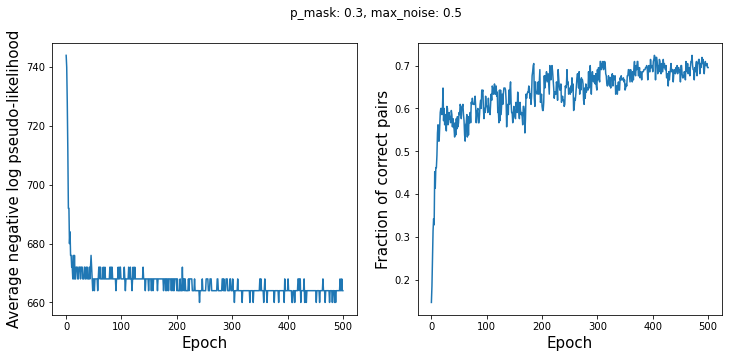

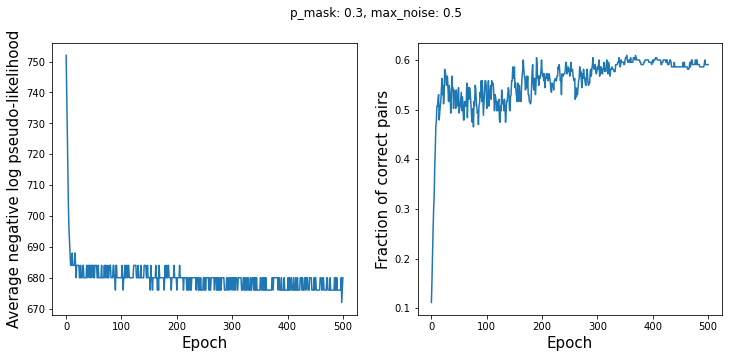

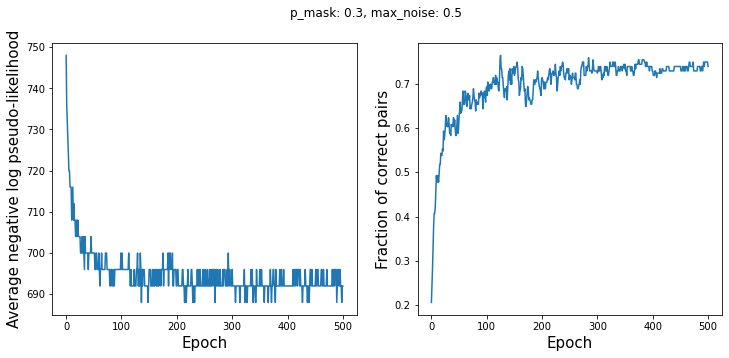

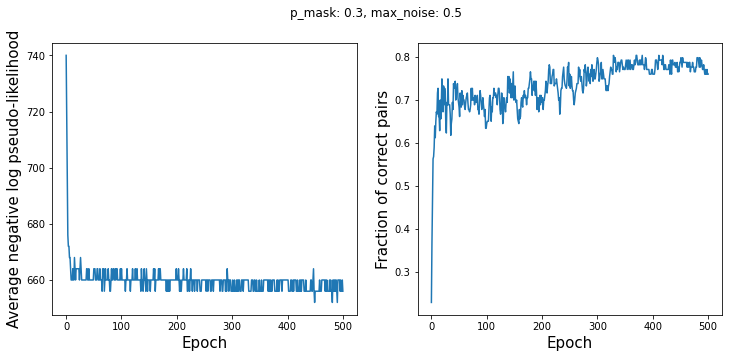

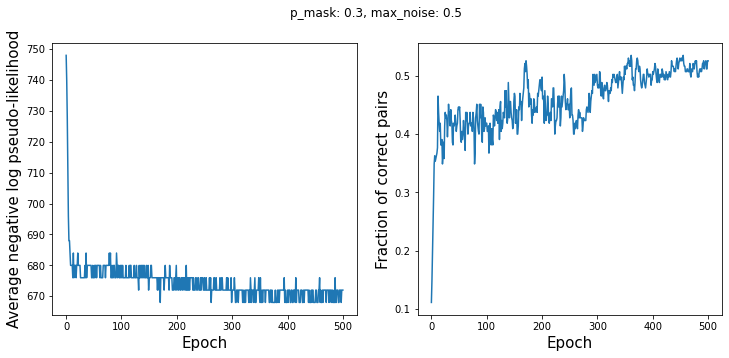

In [3]:
# Load data 
RESULTS_DIR = "results/pairing/malg_malk_256/"
msa_data = [read_msa("../../DiffPALM/nbs/data/MALG-MALK/MALG_cov75_hmmsearch_extr5000_withLast_b.fasta", -1),
            read_msa("../../DiffPALM/nbs/data/MALG-MALK/MALK_cov75_hmmsearch_extr5000_withLast_b.fasta", -1)]
get_species_name = (lambda strn: strn.split("_")[-1])
nSeqs = 256
EPOCHS = 500

p_mask = 0.3
max_noise = 0.5
min_noise = 0.1
n_perm_thresh = np.inf
q = 400
ema_alpha = 0
ema_alpha = round(ema_alpha, 1)

parameters_train = {
    "epochs": EPOCHS,
    "random_init": True,
    "coverage_threshold_potts_model": 0.7,
    "noise_scheduler": "cosine",
    "max_noise": max_noise,
    "potts_model_ema_alpha": ema_alpha,
    "p_mask": p_mask,
    "min_noise": min_noise,
    "random_init": True,
    "n_perm_thresh": n_perm_thresh
}

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
# Baseline after context is created
baseline_alloc = torch.cuda.memory_allocated()
baseline_resv  = torch.cuda.memory_reserved()
torch.cuda.synchronize()

for seed in range(5):
    parameters_dataset = {
        "N": nSeqs,  # Average number of sequences in the input
        "pos": 0,  # Size of the context pairs to use as positive example 
        "max_size": 100,  # Max size of species MSAs (if same as N there is no limit on size)
        "NUMPY_SEED": seed,
        "NUMPY_SEED_OTHER": seed,
    }
    dataset, species_sizes = generate_dataset(
        parameters_dataset, msa_data, get_species_name=get_species_name, verbose=False
    )
    all_seq_set = set()
    filtered_dataset = {'msa': {'left': [], 'right': []}, 'positive_examples': None}
    for i in range(len(dataset['msa']['left'])):
        curr_seq = dataset['msa']['left'][i][1] + dataset['msa']['right'][i][1]
        if curr_seq not in all_seq_set:
            filtered_dataset['msa']['left'].append(dataset['msa']['left'][i])
            filtered_dataset['msa']['right'].append(dataset['msa']['right'][i])
            all_seq_set.add(curr_seq)
    curr_taxid = get_species_name(dataset['msa']['left'][0][0])
    curr_taxid_size = 1
    filtered_species_sizes = []
    solo_seq_idx_l = []
    for i in range(1, len(filtered_dataset['msa']['left'])):
        if get_species_name(filtered_dataset['msa']['left'][i][0]) == curr_taxid:
            curr_taxid_size += 1
        else:
            if curr_taxid_size == 1:
                solo_seq_idx_l.append(i-1)
            filtered_species_sizes.append(curr_taxid_size)
            curr_taxid = get_species_name(filtered_dataset['msa']['left'][i][0])
            curr_taxid_size = 1
    filtered_species_sizes.append(curr_taxid_size)
    if curr_taxid_size == 1:
        solo_seq_idx_l.append(len(filtered_dataset['msa']['left']) - 1)
    tokenized_dataset = dataset_tokenizer(filtered_dataset, device=device)
    # Get ESM tokens and convert to MSA Pairformer tokens
    esm_tokens_left = tokenized_dataset["msa"]["left"].argmax(dim=-1)
    esm_tokens_right = tokenized_dataset["msa"]["right"].argmax(dim=-1)
    # Remove singletons
    nonsingle_mask_t = torch.ones(esm_tokens_left.shape[1], dtype=torch.bool)
    nonsingle_mask_t[solo_seq_idx_l] = False
    esm_tokens_left = esm_tokens_left[:, nonsingle_mask_t, :]
    esm_tokens_right = esm_tokens_right[:, nonsingle_mask_t, :]
    filtered_species_sizes = np.array([s for s in filtered_species_sizes if s > 1])

    # Map ESM tokens to MSA Pairformer tokens and remove CLS token
    mp_tokenized_msa_left_t = torch.from_numpy(
        np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_left.cpu().numpy())
    )[:, :, 1:].cpu()
    mp_tokenized_msa_right_t = torch.from_numpy(
        np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_right.cpu().numpy())
    )[:, :, 1:].cpu()
    # One hot encode the tokens
    mp_ohe_msa_left_t = torch.nn.functional.one_hot(mp_tokenized_msa_left_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
    mp_ohe_msa_right_t = torch.nn.functional.one_hot(mp_tokenized_msa_right_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
    tokenized_dataset["msa"]["left"] = mp_ohe_msa_left_t # (1, N, L_left, 28)
    tokenized_dataset["msa"]["right"] = mp_ohe_msa_right_t # (1, N, L_right, 28)

    left_msa, right_msa = tokenized_dataset["msa"]["left"], tokenized_dataset["msa"]["right"]
    positive_examples = tokenized_dataset["positive_examples"] # empty

    # Designate the first sequence in the MSA as the query sequence
    # This will be a positive example and will be unchanged throughout optimization
    num_positive = 1
    positive_examples = torch.cat(
        (left_msa[:, :num_positive, :, :], right_msa[:, :num_positive, :, :]),
        dim=2
    ).to(device)
    left_msa_train = left_msa[:, num_positive:, :, :]
    right_msa_train = right_msa[:, num_positive:, :, :]
    filtered_species_sizes[0] = filtered_species_sizes[0] - 1
    # Make sure the first species has at least 2 sequences
    if filtered_species_sizes[0] < 2:
        filtered_species_sizes = filtered_species_sizes[1:]
        left_msa_train = left_msa_train[:, 1:, :, :]
        right_msa_train = right_msa_train[:, 1:, :, :]

    parameters_init = {
        "model": msa_pairformer,
        "mrf_head": mrf_head,
        "species_sizes": filtered_species_sizes,
        "device": device,
        "random_seed": seed,
        "compile": False,
        "query_biasing": True,
        "potts_layer_idx": 15
    }
    res_d = {}
    pair_optimizer = MP_EM(**parameters_init)
    start_time = time.time()
    losses, perm_mats, delta_ts = pair_optimizer.train(
        left_msa_train,
        right_msa_train,
        positive_examples=positive_examples,
        **parameters_train
    )
    end_time = time.time()

    f, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(losses)
    ax[0].set_ylabel("Average negative log pseudo-likelihood", size=15)
    ax[0].set_xlabel("Epoch", size=15)
    ax[1].plot([np.trace(perm_mat)/perm_mat.shape[0] for perm_mat in perm_mats])
    ax[1].set_ylabel("Fraction of correct pairs", size=15)
    ax[1].set_xlabel("Epoch", size=15)
    f.suptitle(f"p_mask: {p_mask}, max_noise: {max_noise}")
    print(f"p_mask: {p_mask}, max_noise: {max_noise}")
    print("\tNumber of correct pairs: {}".format(np.trace(perm_mats[np.argmin(losses)]) / np.sum(perm_mats[np.argmin(losses)].shape[0])))

    # Get q lowest losses
    q_lowest_losses = np.argsort(losses)[:400]
    avg_perm_mat = torch.stack([perm_mats[i].to(torch.float32) for i in q_lowest_losses]).mean(dim=0)
    row_ind, col_ind = linear_sum_assignment(-avg_perm_mat)
    final_perm_mat = torch.zeros(sum(filtered_species_sizes), sum(filtered_species_sizes))
    final_perm_mat[row_ind, col_ind] = 1
    print("\tNumber of correct pairs: {}".format(np.trace(final_perm_mat) / np.sum(final_perm_mat.shape[0])))
    res_d = {
        'losses': losses,
        'perm_mats': perm_mats,
        'total_runtime': end_time - start_time
    }
    with open(Path(f"{RESULTS_DIR}/mp_em_results.seed_{seed}.pkl"), "wb") as f:
        pickle.dump(res_d, f)

peak_alloc = torch.cuda.max_memory_allocated()
peak_resv  = torch.cuda.max_memory_reserved()
memory_stats_d = {
    "peak_alloc_GB": peak_alloc / 1024**3,
    "peak_resv_GB":  peak_resv  / 1024**3,
    "incr_peak_alloc_GB": (peak_alloc - baseline_alloc) / 1024**3,
    "incr_peak_resv_GB":  (peak_resv  - baseline_resv)  / 1024**3,
}
with open(Path(f"{RESULTS_DIR}/mp_em_memory_usage.pkl"), "wb") as f:
    pickle.dump(memory_stats_d, f)